In [2]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt

### Save max energy wave fields

In [ ]:
### Generate maxe data
ds = xr.open_dataset('/Users/jwu/Work/Code/wavecnn/data/202109.nc')
hs = np.swapaxes(ds.hs.values, 0, 1)
lp = np.swapaxes(ds.lp.values, 0, 1)
dm = np.swapaxes(ds.dm.values, 0, 1)
dspr = np.swapaxes(ds.dspr.values, 0, 1)
hs_fill = np.nan_to_num(hs, nan=0.0)   

wave_max = np.zeros((hs.shape[0], 4, hs.shape[-2], hs.shape[-1]))
for i in range(hs.shape[0]):
    max_hs = np.max(hs_fill[i], axis=0)
    max_idx  = np.argmax(hs_fill[i], axis=0)
    I = np.arange(max_idx.shape[0])[:, None]
    J = np.arange(max_idx.shape[1])[None, :]
    max_lp = lp[i][max_idx, I, J]
    max_dm = dm[i][max_idx, I, J]
    max_dspr = dspr[i][max_idx, I, J]
    wave_max[i] = np.stack([max_hs, max_lp, max_dm, max_dspr], axis=0)
np.save('wave_maxe.npy', wave_max)

Text(0.5, 1.0, 'Directional Spread (deg)')

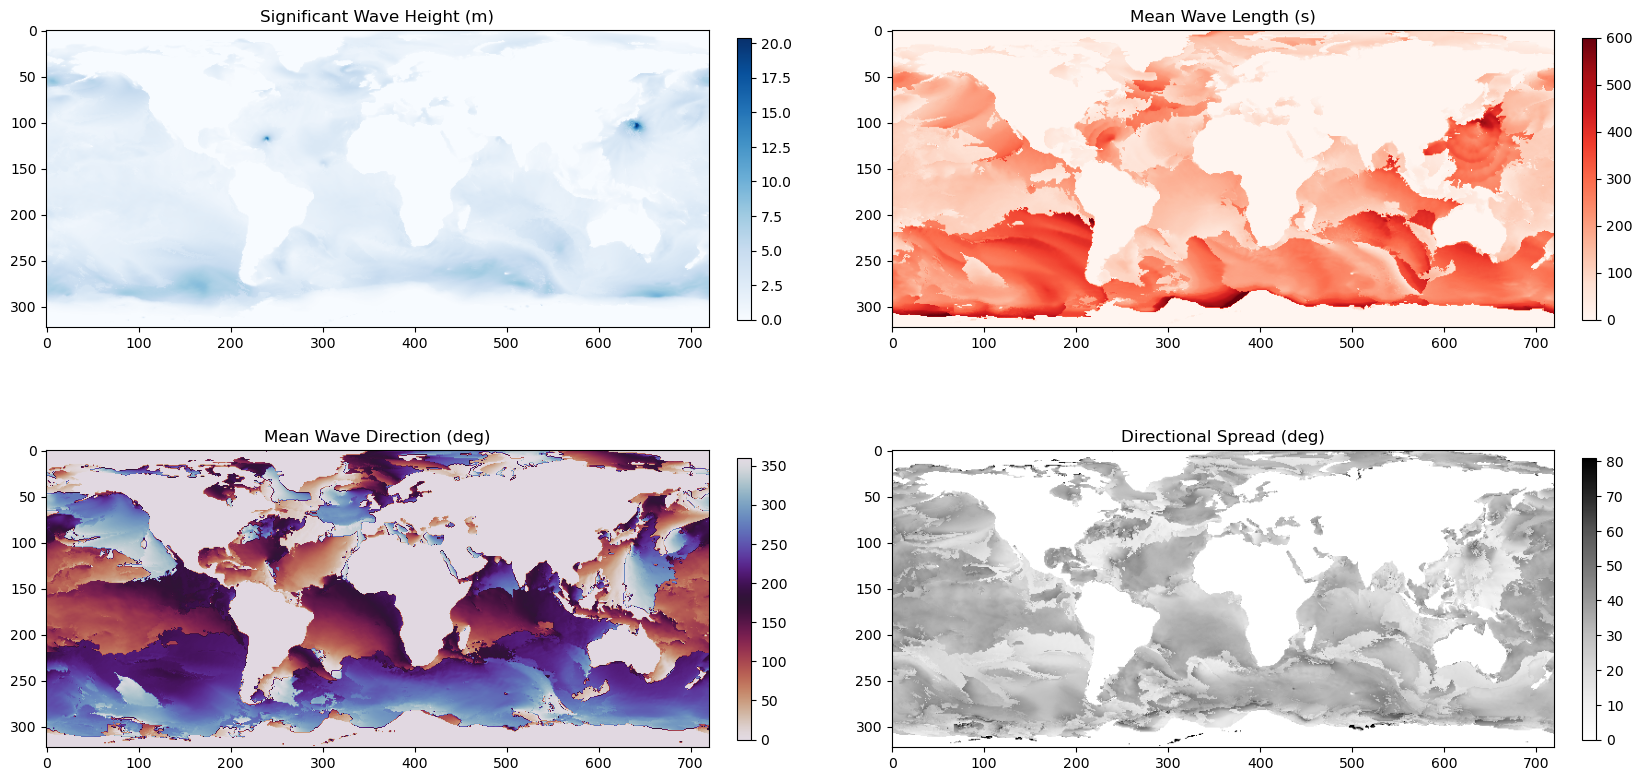

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
img0 = axes[0,0].imshow(wave_max[-1][0][::-1], cmap='Blues')
img1 = axes[0,1].imshow(wave_max[-1][1][::-1], vmin=0, vmax=600, cmap='Reds')
img2 = axes[1,0].imshow(wave_max[-1][2][::-1], cmap='twilight_r')
img3 = axes[1,1].imshow(wave_max[-1][3][::-1], cmap='Greys')
plt.colorbar(img0, ax=axes[0,0], fraction=0.02, pad=0.04)
plt.colorbar(img1, ax=axes[0,1], fraction=0.02, pad=0.04)
plt.colorbar(img2, ax=axes[1,0], fraction=0.02, pad=0.04)
plt.colorbar(img3, ax=axes[1,1], fraction=0.02, pad=0.04)
axes[0,0].set_title('Significant Wave Height (m)')
axes[0,1].set_title('Mean Wave Length (m)')
axes[1,0].set_title('Mean Wave Direction (deg)')
axes[1,1].set_title('Directional Spread (deg)')

### Save mean wave fields

In [ ]:
### Generate mean data
ds_all = xr.open_dataset('/Users/jwu/Work/Code/wavecnn/data/LOPS_WW3-GLOB-30M_202109.nc')
hs_mean = ds_all.hs.values
lp_mean = ds_all.lm.values
dir_mean = ds_all.dir.values
spr_mean = ds_all.spr.values
mean = np.stack([hs_mean, lp_mean, dir_mean, spr_mean], axis=0)
mean = np.swapaxes(mean, 0, 1)
np.save('wave_mean.npy', mean)

Text(0.5, 1.0, 'Directional Spread (deg)')

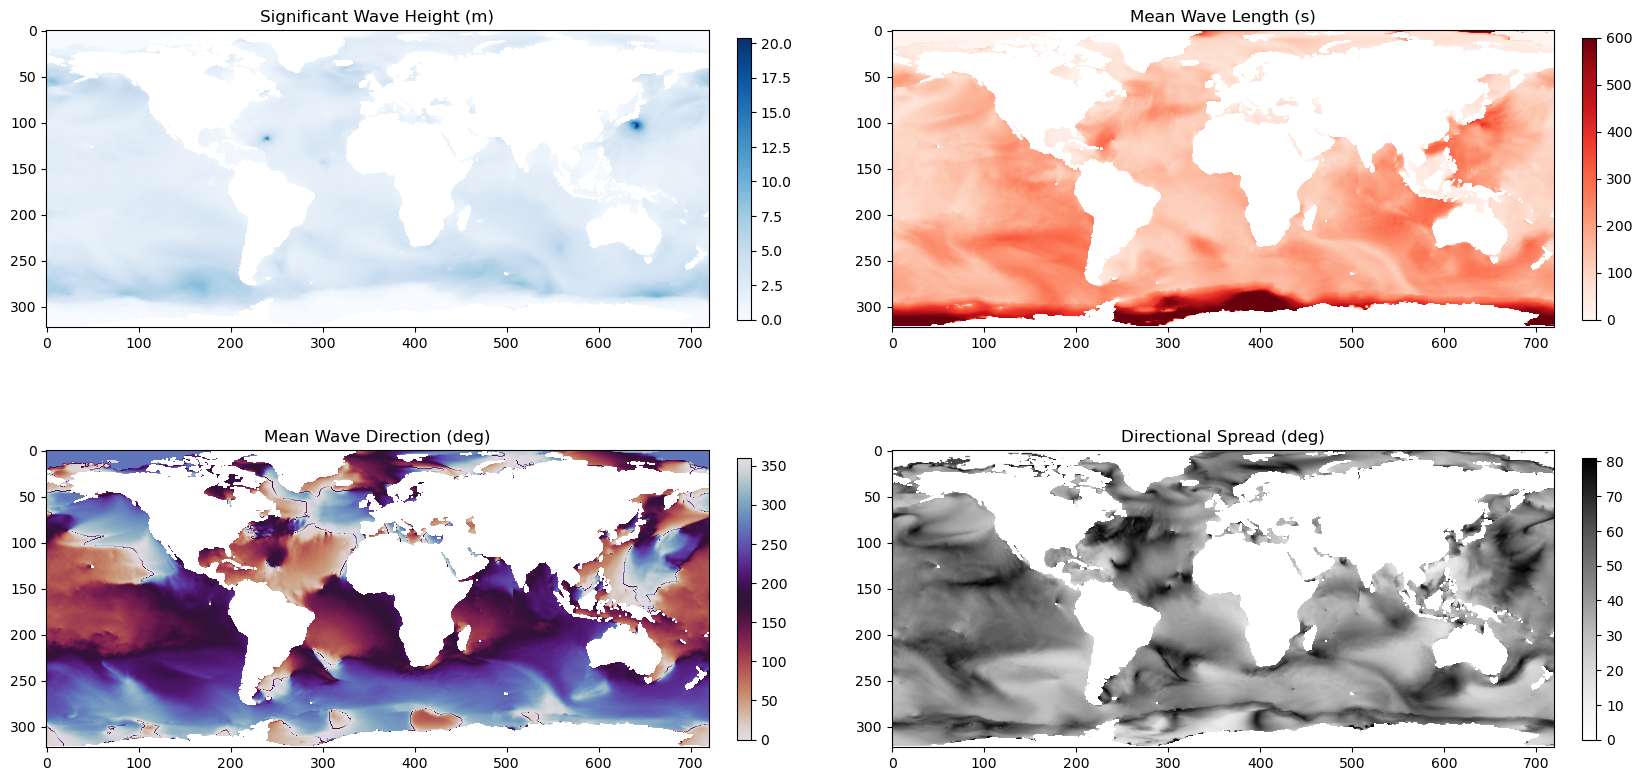

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
img0 = axes[0,0].imshow(mean[-1][0][::-1], cmap='Blues')
img1 = axes[0,1].imshow(mean[-1][1][::-1], vmin=0, vmax=600, cmap='Reds')
img2 = axes[1,0].imshow(mean[-1][2][::-1], cmap='twilight_r')
img3 = axes[1,1].imshow(mean[-1][3][::-1], cmap='Greys')
plt.colorbar(img0, ax=axes[0,0], fraction=0.02, pad=0.04)
plt.colorbar(img1, ax=axes[0,1], fraction=0.02, pad=0.04)
plt.colorbar(img2, ax=axes[1,0], fraction=0.02, pad=0.04)
plt.colorbar(img3, ax=axes[1,1], fraction=0.02, pad=0.04)
axes[0,0].set_title('Significant Wave Height (m)')
axes[0,1].set_title('Mean Wave Length (m)')
axes[1,0].set_title('Mean Wave Direction (deg)')
axes[1,1].set_title('Directional Spread (deg)')

### Save forcing

In [9]:
ds = xr.open_dataset('/Users/jwu/Work/Code/wavecnn/data/202109.nc')

In [ ]:
forcing = np.stack([ds.uwnd.values, ds.vwnd.values, ds.dpt.values, ds.ice.values], axis=0)
np.save('forcing.npy', np.swapaxes(forcing, 0, 1))

### Check resizing

In [ ]:
from torchvision import transforms
import torch
transform = transforms.Resize((320, 320))

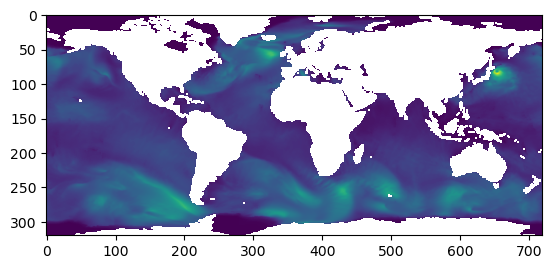

In [ ]:
a = np.load('../datasets/wave_mean.npy')
b = a[:2, :, 1:-2,:]
print(b.shape)
plt.imshow(b[::-1])

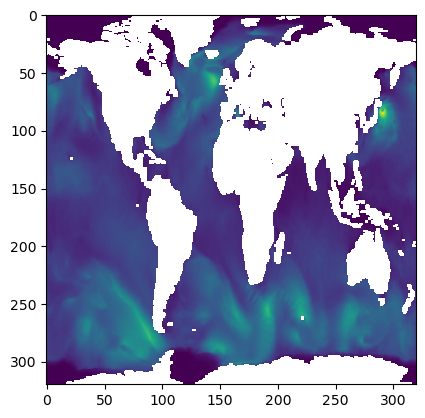

In [ ]:
b_resized = transform(torch.tensor(b))
b_ = b_resized[0,0,:,:].numpy()
plt.imshow(b_[::-1])

In [4]:
mask = np.load('../datasets/mask.npy')
mask = mask[1:-2,:]
mask = mask.reshape(1, 1, mask.shape[0], mask.shape[1])

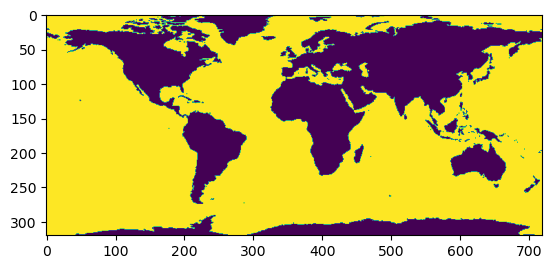

In [5]:
plt.imshow(mask[0,0,::-1])

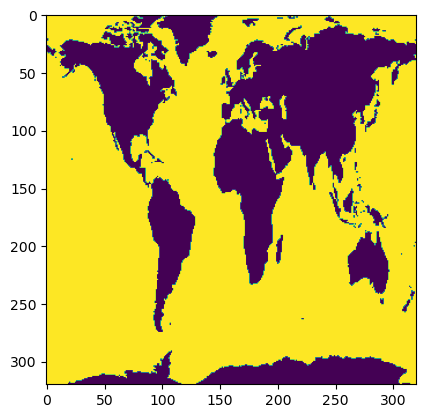

In [7]:
mask_resized = transform(torch.tensor(mask))
mask_ = mask_resized[0,0,:,:].numpy()
plt.imshow(mask_[::-1])

### Latitude weighting

In [ ]:
ds = xr.open_dataset('/global/homes/j/jiarongw/scratch_folder/wave_data/raw/LOPS_WW3-GLOB-30M_202109.nc')

In [19]:
lat = np.deg2rad(ds.latitude[1:-2].values)
wlat = np.cos(lat) / np.average(np.cos(lat))
wlat = np.repeat(wlat[:, None], 720, axis=1)
np.save('/global/homes/j/jiarongw/scratch_folder/wave_data/wlat.npy', wlat)